In [58]:
import os
import argparse
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from tqdm import tqdm
import shap
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import joblib

from models import make
from models.t0 import T0RegressionModel  # noqa: F401
from datahandles import FewShotDataset
from utils import load_cfg, dict_to_mlp


def load_dataset(cfg, test_list, n_shots, n_queries, max_n_features, test_size=1, permutation=False):
    """Create train and test FewShotDataset objects."""
    train_ds = FewShotDataset(
        dataset_names=test_list,
        data_root=cfg.datasets.data_root,
        split='train',
        split_size=cfg.datasets.train_size,
        n_shots=cfg.datasets.n_shots,
        n_queries=cfg.datasets.n_queries,
        queries_same_as_shots=cfg.datasets.queries_same_as_shots,
        max_n_features=max_n_features,
        balance_labels=True,
        col_permutation=permutation,
        shuffle=False,
        debug=False,
        random_seed=cfg.random_state,
        shots_with_labels=True
    )

    test_ds = FewShotDataset(
        dataset_names=test_list,
        data_root=cfg.datasets.data_root,
        split='test',
        split_size=test_size,
        n_shots=n_shots,
        n_queries=n_queries,
        queries_same_as_shots=True,
        max_n_features=max_n_features,
        balance_labels=False,
        col_permutation=permutation,
        shuffle=True,
        debug=False,
        random_seed=True,
        shots_with_labels=False
    )
    return test_ds, train_ds


def get_mlp(model, cfg, ds_name, n_shots, n_queries, n_samples, max_n_features, 
            post_training, post_training_epochs, permutation):
    if n_shots < 1:
        test_ds, train_ds = load_dataset(cfg, [ds_name], n_shots=n_queries, n_queries=n_queries,
                                         test_size=n_samples, max_n_features=max_n_features,
                                         permutation=permutation)
    else:
        test_ds, train_ds = load_dataset(cfg, [ds_name], n_shots=n_shots, n_queries=n_queries,
                                         test_size=n_samples, max_n_features=max_n_features,
                                         permutation=permutation)

    X = test_ds[0]['queries_x']
    y = test_ds[0]['queries_y']

    X_train, y_train = [], []
    for query in train_ds:
        X_train.extend(query['queries_x'])
        y_train.extend(query['queries_y'])
    
    
    hyponet = dict_to_mlp(weight_dict=model(train_ds[0]).params, in_dim=X.shape[1]).cuda()

    if post_training:
        epochs = post_training_epochs    
        loss_fn = nn.BCEWithLogitsLoss()
        opt = optim.Adam(hyponet.parameters(), lr=1e-3)

        best_val_auc = -1.0
        best_epoch = -1
        for ep in range(1, epochs + 1):
            hyponet.train()
            for query in train_ds:
                xb = query["queries_x"]
                yb = query["queries_y"].to(torch.float)

                xb = xb.to("cuda")
                yb = yb.to("cuda")
                opt.zero_grad()
                logits = hyponet(xb)
                loss = loss_fn(logits[:,1], yb)
                loss.backward()
                opt.step()
            # Validate
            hyponet.eval()
            ys, preds = [], []
            with torch.no_grad():
                for query in train_ds:
                    xb = query["queries_x"]
                    yb = query["queries_y"].to(torch.float)
                    xb = xb.to("cuda")
                    logits = hyponet(xb)
                    probs = torch.sigmoid(logits).cpu().numpy()
                    preds.append(probs)
                    ys.append(yb.numpy())
            ys = np.concatenate(ys)
            preds = np.concatenate(preds)
            val_auc = roc_auc_score(y_true=ys, y_score=preds[:,1])
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_epoch = ep
    hyponet.eval()

    # log_reg = LogisticRegression(max_iter=1000)
    # log_reg.fit(X_train.cpu().numpy(), y_train.cpu().numpy())

    if len(permutation) <= X.shape[1]:
        permutation = permutation.copy()
        permutation.extend([i for i in range(X.shape[1]) if i not in permutation])
    return {'mlp': hyponet, 
            'X': X, 
            'y': y, 
            'perm': permutation}

def shap_summary_plot_classification(model, X, feature_names=None, nsamples=100, device="cpu", class_idx=None):
    """
    Compute and plot SHAP summary plot for a PyTorch classification model.
    
    Works for binary (2 logits) and multi-class (C logits).
    
    Args:
        model (torch.nn.Module): Trained PyTorch model (output shape: [N, C]).
        X (np.ndarray or torch.Tensor): Input data.
        feature_names (list[str], optional): Feature names for labeling the plot.
        nsamples (int): Number of samples to explain (for efficiency).
        device (str): "cpu" or "cuda".
        class_idx (int or None): Which class to explain.
            - If None: defaults to 1 for binary classification, 0 for multi-class.
    
    Returns:
        shap_values: SHAP values (list if multi-class).
    """
    # model.eval()
    # model.to(device)

    # Convert to tensor if numpy
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X, dtype=torch.float32)
    
    # Select subset for SHAP
    if X.shape[0] > nsamples:
        X_summary = X[:nsamples].to(device)
    else:
        X_summary = X.to(device)

    # Prediction wrapper: return probabilities
    def f(x):
        with torch.no_grad():
            logits = model(torch.tensor(x, dtype=torch.float32).to(device))  # convert back to tensor
            probs = torch.softmax(logits, dim=1)     # [N, C]
            return probs.detach().cpu().numpy()

    # Explicit masker for tabular data
    masker = shap.maskers.Independent(X_summary.cpu().numpy())

    # SHAP Explainer
    explainer = shap.Explainer(f, masker)
    shap_values = explainer(X_summary.cpu().numpy())

    # Decide default class_idx
    num_classes = shap_values.values.shape[-1]
    if class_idx is None:
        class_idx = 1 if num_classes == 2 else 0

    # Extract SHAP values for chosen class
    class_shap = shap_values[:, :, class_idx]

    # Plot summary
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        class_shap,
        X_summary.cpu().numpy(),
        feature_names=feature_names,
        show=True
    )

    return shap_values


In [59]:
xgb_clf = xgb.XGBClassifier()
xgb_clf.load_model("checkpoints/calhousing/n16/seed_14/xgboost.json")

log_reg = clf = joblib.load("checkpoints/calhousing/n16/seed_14/logistic.pkl")

checkpoint_path = "save/tabpfn-calhousing-n16-seed14/epoch-best-balacc.pth"
post_training = True
pt_epochs = 100

device = "cuda"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
cfg = load_cfg(cfg_dict=checkpoint["cfg"])
model = make(model_name=cfg.hypernet.name, cfg=cfg, sd=checkpoint["model"]).to(device)

if "tokenizer" in cfg.keys():
    tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer.model)
    def model_fn(query):
                
        tokens = tokenizer(query["shots"], 
                        truncation=cfg.tokenizer.truncation, 
                        padding=cfg.tokenizer.padding, 
                        max_length=cfg.tokenizer.max_length,
                        return_tensors='pt')
        return model(tokens.to("cuda"))
else:
    def model_fn(query):
        return model(query)

total_training_set_size = cfg.datasets.n_shots * cfg.datasets.train_size \
    if cfg.datasets.queries_same_as_shots \
    else (cfg.datasets.n_queries + cfg.datasets.n_shots) * cfg.datasets.train_size

ds_name = cfg.datasets.list_combine_train[0]
max_n_features = cfg.hyponet.in_dim
n_samples = 1
n_queries_dict = {"bank": 43211, "blood": 374, "calhousing": 19640, "income": 44222}
n_queries = n_queries_dict[ds_name]
n_shots = total_training_set_size

mlp_dict1 = get_mlp(model=model_fn,
              cfg=cfg,
              ds_name=ds_name,
              n_shots=n_shots,
              n_queries=n_queries,
              n_samples=n_samples,
              max_n_features=max_n_features,
              post_training=post_training,
              post_training_epochs=pt_epochs,
              permutation=[])

mlp_dict2 = get_mlp(model=model_fn,
              cfg=cfg,
              ds_name=ds_name,
              n_shots=n_shots,
              n_queries=n_queries,
              n_samples=n_samples,
              max_n_features=max_n_features,
              post_training=post_training,
              post_training_epochs=pt_epochs,
              permutation=[7,1,0])




In [60]:
mlp1, X1, y1, perm1 = mlp_dict1['mlp'], mlp_dict1['X'].cuda(), mlp_dict1['y'].cuda(), mlp_dict1['perm']
mlp2, X2, y2, perm2 = mlp_dict2['mlp'], mlp_dict2['X'].cuda(), mlp_dict2['y'].cuda(), mlp_dict2['perm']

columns = {
    "median income": {"type": "numerical"},
    "housing median age": {"type": "numerical"},
    "total rooms": {"type": "numerical"},
    "total number of bedrooms": {"type": "numerical"},
    "population": {"type": "numerical"},
    "number of households": {"type": "numerical"},
    "latitude": {"type": "numerical"},
    "longitude": {"type": "numerical"},
    "y_temp": {"type": "categorical", "values": ['no', 'yes']},
    "target_name": "y_temp"
}

def get_feature_columns(columns_dict):
    feature_cols = []
    target_col = columns_dict.get("target_name", None)
    
    for col, spec in columns_dict.items():
        # skip target_name entry (it is just a string)
        if col == "target_name":
            continue
        if col == columns_dict["target_name"]:
            continue
        
        if spec["type"] == "numerical":
            feature_cols.append(col)
        elif spec["type"] == "categorical":
            for val in spec["values"]:
                feature_cols.append(f"{col}_{val}")
        else:
            raise ValueError(f"Unknown type for column {col}")
    
    return feature_cols

feature_columns = get_feature_columns(columns)
feature_columns.append("all_zeros")
print("Feature columns:", feature_columns)


Feature columns: ['median income', 'housing median age', 'total rooms', 'total number of bedrooms', 'population', 'number of households', 'latitude', 'longitude', 'all_zeros']


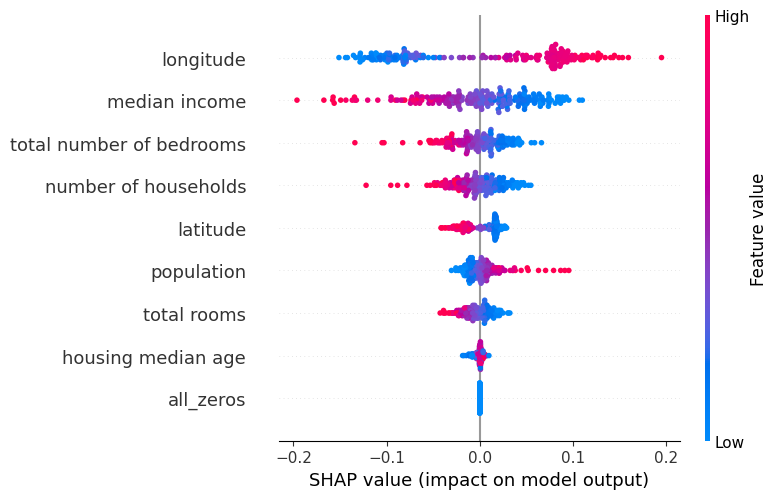

In [61]:
shap_values = shap_summary_plot_classification(
    model=mlp1.cpu(),
    X=X1,
    feature_names=[feature_columns[i] for i in perm1],
    nsamples=200,
    class_idx=0  # positive class
)

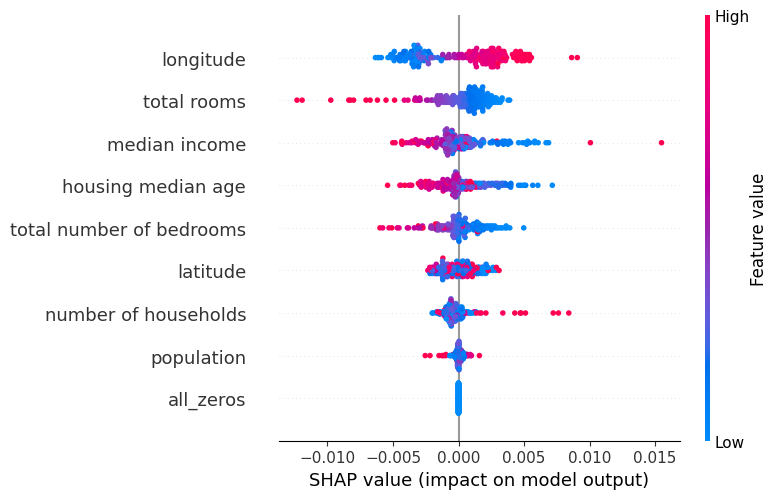

In [62]:
shap_values = shap_summary_plot_classification(
    model=mlp2.cpu(),
    X=X2,
    feature_names=[feature_columns[i] for i in perm2],
    nsamples=200,
    class_idx=0  # positive class
)

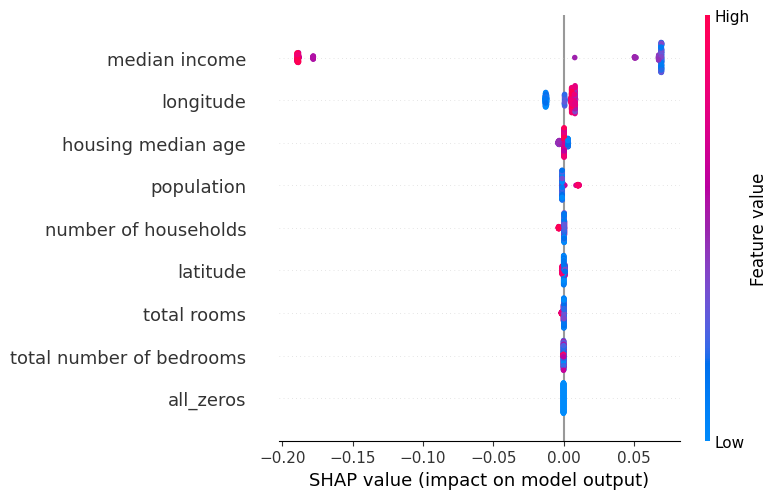

In [63]:
xgb_model = lambda x: torch.tensor(xgb_clf.predict_proba(x))
shap_values = shap_summary_plot_classification(
    model=xgb_model,
    X=X1,
    feature_names=[feature_columns[i] for i in perm1],
    nsamples=200,
    class_idx=0  # positive class
)

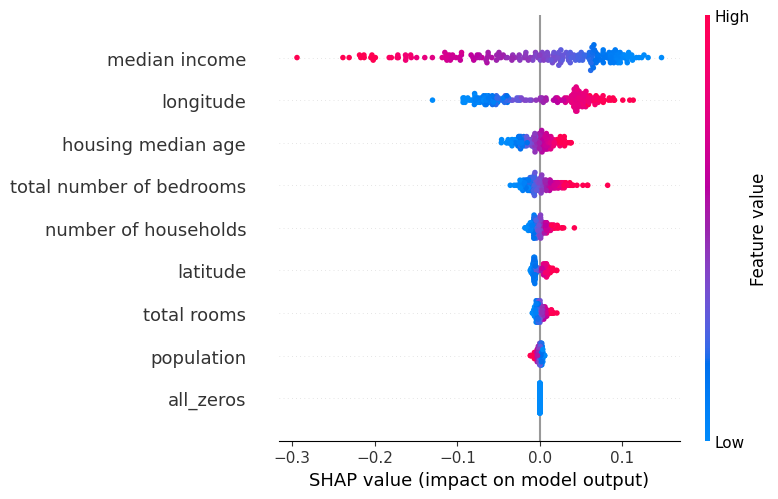

In [64]:
lr_model = lambda x: torch.tensor(log_reg.predict_proba(x))
shap_values = shap_summary_plot_classification(
    model=lr_model,
    X=X1,
    feature_names=[feature_columns[i] for i in perm1],
    nsamples=200,
    class_idx=0  # positive class
)